# 와인 품질 예측 - Best Practice 워크플로우

이 노트북은 데이터 누수(Data Leakage)를 방지하는 Best Practice 워크플로우를 따릅니다.

## 워크플로우 순서
1. **데이터 로드**: CSV 파일 로드
2. **Train/Test 분리 (먼저!)**: Stratified Split으로 80:20 분리
3. **EDA**: Train 데이터만으로 분석 (Test는 봉인)
4. **전처리**: Train 기준으로 fit → Test에 transform
5. **클래스 불균형 처리**: Train 내에서만 SMOTETomek 적용
6. **모델 학습 및 튜닝**: MLflow 로깅
7. **최종 평가**: 봉인된 Test 데이터로 단 한 번 평가


## Section 1. 환경 설정 및 데이터 로드


In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('seaborn-v0_8')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_palette("husl")
%matplotlib inline

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# imbalanced-learn
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# MLflow
import mlflow
import mlflow.sklearn

print("라이브러리 로드 완료!")


라이브러리 로드 완료!


In [2]:
# 데이터 로드
csv_path = 'wine_data_homework.csv'
df = pd.read_csv(csv_path)

print(f"원본 데이터 크기: {df.shape}")
print(f"\n컬럼 목록: {df.columns.tolist()}")

# 불필요한 인덱스 컬럼 제거
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("\n인덱스 컬럼 제거 완료")

print(f"\n정리 후 데이터 크기: {df.shape}")
df.head()


원본 데이터 크기: (4001, 13)

컬럼 목록: ['Unnamed: 0', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

인덱스 컬럼 제거 완료

정리 후 데이터 크기: (4001, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Section 2. Train/Test 분리 (먼저!)

**핵심**: 모든 전처리/분석 전에 먼저 데이터를 분리합니다.
- Test 데이터는 최종 평가 전까지 절대 사용하지 않습니다.
- Stratified Split으로 Quality 분포를 유지합니다.


In [3]:
# 피처와 타겟 분리
X = df.drop('quality', axis=1)
y = df['quality']

print("=" * 80)
print("=== Train/Test 분리 (Stratified Split) ===")
print("=" * 80)

# Stratified Split: Quality 분포를 유지하면서 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Quality 분포 유지
)

print(f"\n전체 데이터: {len(df)}개")
print(f"Train 데이터: {len(X_train)}개 ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test 데이터: {len(X_test)}개 ({len(X_test)/len(df)*100:.1f}%)")

# 분포 확인
print(f"\n=== Quality 분포 비교 ===")
print(f"\nTrain 분포:")
train_dist = y_train.value_counts().sort_index()
print(train_dist)
print(f"비율: {(train_dist / len(y_train) * 100).round(2).to_dict()}")

print(f"\nTest 분포:")
test_dist = y_test.value_counts().sort_index()
print(test_dist)
print(f"비율: {(test_dist / len(y_test) * 100).round(2).to_dict()}")

print(f"\n" + "=" * 80)
print("⚠️  Test 데이터는 Section 7까지 사용하지 않습니다!")
print("=" * 80)


=== Train/Test 분리 (Stratified Split) ===

전체 데이터: 4001개
Train 데이터: 3200개 (80.0%)
Test 데이터: 801개 (20.0%)

=== Quality 분포 비교 ===

Train 분포:
quality
3      15
4     114
5     971
6    1374
7     597
8     125
9       4
Name: count, dtype: int64
비율: {3: 0.47, 4: 3.56, 5: 30.34, 6: 42.94, 7: 18.66, 8: 3.91, 9: 0.12}

Test 분포:
quality
3      4
4     28
5    243
6    344
7    150
8     31
9      1
Name: count, dtype: int64
비율: {3: 0.5, 4: 3.5, 5: 30.34, 6: 42.95, 7: 18.73, 8: 3.87, 9: 0.12}

⚠️  Test 데이터는 Section 7까지 사용하지 않습니다!


## Section 3. EDA (Train 데이터만)

**핵심**: Test 데이터는 절대 보지 않습니다. Train 데이터만으로 분석합니다.


In [4]:
# Train 데이터 기본 통계
print("=" * 80)
print("=== Train 데이터 기본 통계 (Test는 보지 않음!) ===")
print("=" * 80)

X_train.describe()


=== Train 데이터 기본 통계 (Test는 보지 않음!) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,6.974031,0.276006,0.342163,6.349453,0.045626,35.582656,140.564687,0.994202,3.191562,0.489319,10.457312
std,0.842058,0.099775,0.123171,5.101460,0.021767,16.860769,43.481561,0.003001,0.154558,0.113699,1.216566
min,4.200000,0.080000,0.000000,0.600000,0.014000,2.000000,9.000000,0.987130,2.740000,0.220000,8.000000
25%,6.400000,0.210000,0.270000,1.700000,0.036000,23.000000,109.000000,0.991888,3.090000,0.410000,9.400000
50%,6.900000,0.260000,0.320000,5.200000,0.043000,34.000000,137.000000,0.993900,3.170000,0.470000,10.300000
75%,7.400000,0.320000,0.400000,9.700000,0.050000,47.000000,170.000000,0.996280,3.290000,0.550000,11.300000
max,14.200000,1.005000,1.660000,65.800000,0.346000,146.500000,366.500000,1.038980,3.820000,1.060000,14.000000


=== Train Quality 분포 ===


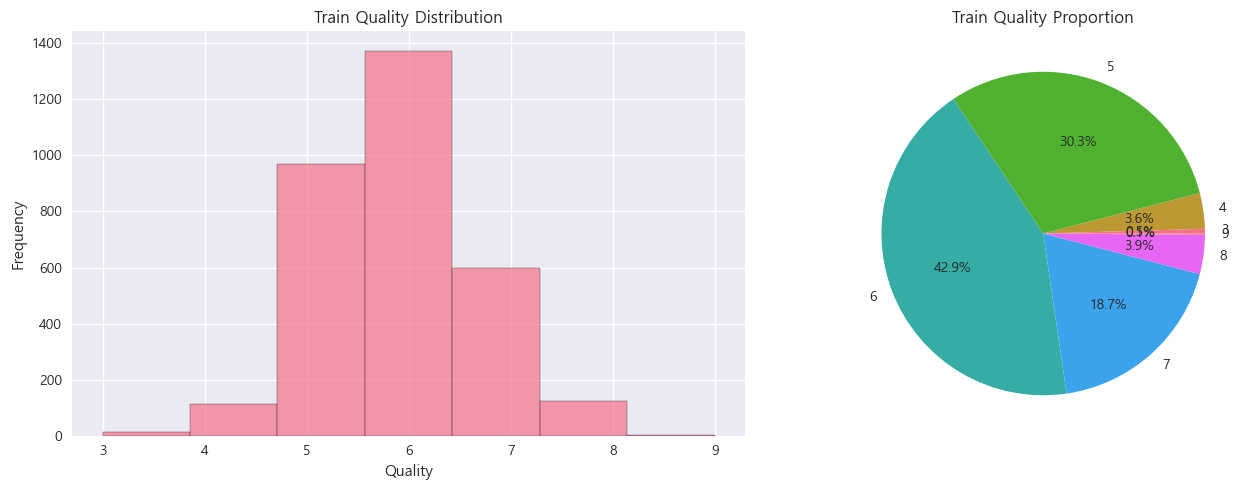


Quality 범위: 3 ~ 9
Quality 5,6 비율: 73.3%


In [5]:
# Train Quality 분포 시각화
print("=== Train Quality 분포 ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(y_train, bins=7, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train Quality Distribution')

# 파이 차트
y_train.value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Train Quality Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nQuality 범위: {y_train.min()} ~ {y_train.max()}")
print(f"Quality 5,6 비율: {((y_train == 5).sum() + (y_train == 6).sum()) / len(y_train) * 100:.1f}%")


In [6]:
# Train 데이터 결측치 확인
print("=== Train 데이터 결측치 확인 ===")
missing_train = X_train.isnull().sum()
print(missing_train)

if missing_train.sum() > 0:
    print(f"\n총 결측치: {missing_train.sum()}개")
else:
    print("\n결측치가 없습니다.")


=== Train 데이터 결측치 확인 ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

결측치가 없습니다.


=== Train 데이터 상관관계 분석 ===


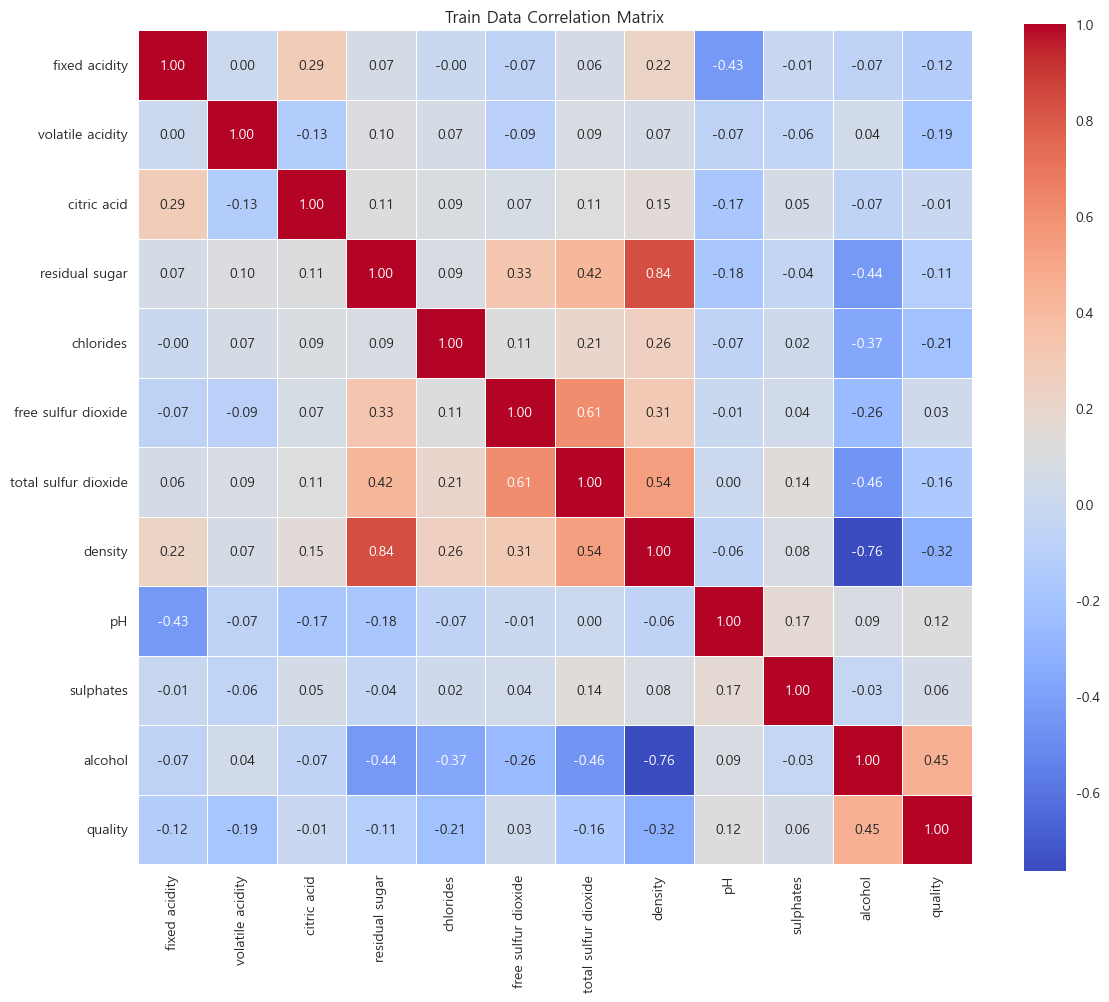


=== Quality와의 상관관계 (Train 기준) ===
alcohol                 0.454800
pH                      0.119342
sulphates               0.059123
free sulfur dioxide     0.027136
citric acid            -0.011094
residual sugar         -0.114293
fixed acidity          -0.122719
total sulfur dioxide   -0.163983
volatile acidity       -0.187644
chlorides              -0.213722
density                -0.323739
Name: quality, dtype: float64


In [7]:
# Train 데이터 상관관계 분석
print("=== Train 데이터 상관관계 분석 ===")

# Train 데이터에 quality 추가하여 상관관계 계산
train_with_target = X_train.copy()
train_with_target['quality'] = y_train

# 상관관계 행렬
corr_matrix = train_with_target.corr()

# 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Train Data Correlation Matrix')
plt.tight_layout()
plt.show()

# Quality와의 상관관계
quality_corr = corr_matrix['quality'].drop('quality').sort_values(ascending=False)
print("\n=== Quality와의 상관관계 (Train 기준) ===")
print(quality_corr)


## Section 4. 전처리 (Train 기준 → Test 적용)

**핵심 원칙**:
- 결측치: Train 평균으로 Train과 Test 모두 채움
- 이상치: Train 기준으로 계산, Train에서만 제거
- 피처 선택: Train 상관관계 기반
- 정규화: Train으로 fit, Test에 transform만


### 4-1. 결측치 처리


In [8]:
# 결측치 처리: Train 평균으로 Train/Test 모두 채움
print("=" * 80)
print("=== 결측치 처리 (Train 평균 사용) ===")
print("=" * 80)

# Train 평균 계산 (이 값을 Test에도 적용)
train_means = X_train.mean()
print("Train 평균값 (결측치 대체용):")
print(train_means.round(4))

# 결측치 채우기
X_train_filled = X_train.fillna(train_means)
X_test_filled = X_test.fillna(train_means)  # Train 평균 사용!

print(f"\nTrain 결측치: {X_train_filled.isnull().sum().sum()}개")
print(f"Test 결측치: {X_test_filled.isnull().sum().sum()}개")


=== 결측치 처리 (Train 평균 사용) ===
Train 평균값 (결측치 대체용):
fixed acidity             6.9740
volatile acidity          0.2760
citric acid               0.3422
residual sugar            6.3495
chlorides                 0.0456
free sulfur dioxide      35.5827
total sulfur dioxide    140.5647
density                   0.9942
pH                        3.1916
sulphates                 0.4893
alcohol                  10.4573
dtype: float64

Train 결측치: 0개
Test 결측치: 0개


### 4-2. 이상치 처리


In [9]:
# 이상치 처리: Train IQR 기준 계산, Train에서만 제거
print("=" * 80)
print("=== 이상치 처리 (Train 기준 IQR, Train에서만 제거) ===")
print("=" * 80)

# Train 데이터 기준으로 IQR 계산
Q1_train = X_train_filled.quantile(0.25)
Q3_train = X_train_filled.quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_bound = Q1_train - 1.5 * IQR_train
upper_bound = Q3_train + 1.5 * IQR_train

print("Train 기준 IQR 범위:")
outlier_bounds = pd.DataFrame({
    'Lower': lower_bound,
    'Upper': upper_bound
})
print(outlier_bounds.round(4))

# Train에서만 이상치 제거 (Test는 그대로 유지!)
outlier_mask = ~((X_train_filled < lower_bound) | (X_train_filled > upper_bound)).any(axis=1)

X_train_clean = X_train_filled[outlier_mask].copy()
y_train_clean = y_train[outlier_mask].copy()

n_outliers = (~outlier_mask).sum()
print(f"\nTrain 이상치 제거: {n_outliers}개 ({n_outliers/len(X_train_filled)*100:.2f}%)")
print(f"Train 데이터: {len(X_train_filled)} → {len(X_train_clean)}개")
print(f"\n⚠️ Test 데이터는 이상치 제거하지 않음: {len(X_test_filled)}개 유지")


=== 이상치 처리 (Train 기준 IQR, Train에서만 제거) ===
Train 기준 IQR 범위:
                        Lower     Upper
fixed acidity          4.9000    8.9000
volatile acidity       0.0450    0.4850
citric acid            0.0750    0.5950
residual sugar       -10.3000   21.7000
chlorides              0.0150    0.0710
free sulfur dioxide  -13.0000   83.0000
total sulfur dioxide  17.5000  261.5000
density                0.9853    1.0029
pH                     2.7900    3.5900
sulphates              0.2000    0.7600
alcohol                6.5500   14.1500

Train 이상치 제거: 564개 (17.62%)
Train 데이터: 3200 → 2636개

⚠️ Test 데이터는 이상치 제거하지 않음: 801개 유지


### 4-3. 피처 선택


In [10]:
# 피처 선택: Train 상관관계 기반
print("=" * 80)
print("=== 피처 선택 (Train 상관관계 기준) ===")
print("=" * 80)

# Train 데이터로 상관관계 재계산 (이상치 제거 후)
train_clean_with_target = X_train_clean.copy()
train_clean_with_target['quality'] = y_train_clean
quality_corr_clean = train_clean_with_target.corr()['quality'].drop('quality').abs().sort_values(ascending=False)

print("Quality와의 상관관계 (절댓값, Train 기준):")
print(quality_corr_clean.round(4))

# 상관관계 0.1 이상인 피처 선택
corr_threshold = 0.1
selected_features = quality_corr_clean[quality_corr_clean >= corr_threshold].index.tolist()

print(f"\n선택된 피처 (|corr| >= {corr_threshold}): {len(selected_features)}개")
print(selected_features)

# 피처 선택 적용
X_train_selected = X_train_clean[selected_features].copy()
X_test_selected = X_test_filled[selected_features].copy()

print(f"\nTrain 피처: {X_train_selected.shape}")
print(f"Test 피처: {X_test_selected.shape}")


=== 피처 선택 (Train 상관관계 기준) ===
Quality와의 상관관계 (절댓값, Train 기준):
alcohol                 0.4391
density                 0.3250
chlorides               0.2876
total sulfur dioxide    0.1587
residual sugar          0.1342
volatile acidity        0.1108
pH                      0.0994
fixed acidity           0.0712
free sulfur dioxide     0.0305
sulphates               0.0289
citric acid             0.0138
Name: quality, dtype: float64

선택된 피처 (|corr| >= 0.1): 6개
['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar', 'volatile acidity']

Train 피처: (2636, 6)
Test 피처: (801, 6)


### 4-4. 정규화


In [11]:
# 정규화: Train으로 fit, Test에 transform만
print("=" * 80)
print("=== 정규화 (Train으로 fit → Test에 transform) ===")
print("=" * 80)

# QuantileTransformer 사용
scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# Train으로 fit_transform
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_selected),
    columns=X_train_selected.columns,
    index=X_train_selected.index
)

# Test에는 transform만! (fit 없음)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_selected),
    columns=X_test_selected.columns,
    index=X_test_selected.index
)

print("정규화 완료!")
print(f"\nTrain 정규화 후 통계:")
print(f"  평균: {X_train_scaled.mean().round(4).tolist()}")
print(f"  표준편차: {X_train_scaled.std().round(4).tolist()}")

print(f"\nTest 정규화 후 통계:")
print(f"  평균: {X_test_scaled.mean().round(4).tolist()}")
print(f"  표준편차: {X_test_scaled.std().round(4).tolist()}")

print(f"\n최종 데이터 크기:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled: {X_test_scaled.shape}")
print(f"  y_train_clean: {len(y_train_clean)}")
print(f"  y_test: {len(y_test)}")


=== 정규화 (Train으로 fit → Test에 transform) ===
정규화 완료!

Train 정규화 후 통계:
  평균: [0.0007, -0.0, 0.0007, -0.0001, 0.0013, -0.0023]
  표준편차: [1.0117, 1.0072, 1.0095, 1.007, 1.0084, 1.0148]

Test 정규화 후 통계:
  평균: [-0.0345, 0.0314, 0.1968, 0.0209, 0.0023, 0.1894]
  표준편차: [1.0151, 1.0366, 1.4557, 1.0156, 1.0539, 1.4202]

최종 데이터 크기:
  X_train_scaled: (2636, 6)
  X_test_scaled: (801, 6)
  y_train_clean: 2636
  y_test: 801


## Section 5. 클래스 불균형 처리

**핵심**: SMOTETomek는 Train 데이터 내에서만 적용합니다.


In [12]:
# SMOTETomek 적용 (Train 데이터 내에서만!)
print("=" * 80)
print("=== SMOTETomek 적용 (Train 내에서만) ===")
print("=" * 80)

# 소수 클래스 최소 샘플 수 확인
min_samples = y_train_clean.value_counts().min()
print(f"소수 클래스 최소 샘플 수: {min_samples}개")

# k_neighbors 설정
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
print(f"SMOTE k_neighbors: {k_neighbors}")

# SMOTETomek 적용
try:
    smotetomek = SMOTETomek(
        smote=SMOTE(k_neighbors=k_neighbors, random_state=42),
        random_state=42
    )
    X_train_resampled, y_train_resampled = smotetomek.fit_resample(X_train_scaled, y_train_clean)
    
    print(f"\n샘플링 전: {len(X_train_scaled)}개")
    print(f"샘플링 후: {len(X_train_resampled)}개")
    print(f"증가율: {(len(X_train_resampled) / len(X_train_scaled) - 1) * 100:.1f}%")
    
    print(f"\n샘플링 후 Quality 분포:")
    print(pd.Series(y_train_resampled).value_counts().sort_index())
    
    SMOTE_SUCCESS = True
except Exception as e:
    print(f"SMOTETomek 실패: {e}")
    X_train_resampled = X_train_scaled.values
    y_train_resampled = y_train_clean.values
    SMOTE_SUCCESS = False

print(f"\n⚠️ Test 데이터는 샘플링하지 않음: {len(X_test_scaled)}개 유지")


=== SMOTETomek 적용 (Train 내에서만) ===
소수 클래스 최소 샘플 수: 3개
SMOTE k_neighbors: 2

샘플링 전: 2636개
샘플링 후: 8014개
증가율: 204.0%

샘플링 후 Quality 분포:
quality
3    1168
4    1168
5    1112
6    1092
7    1138
8    1168
9    1168
Name: count, dtype: int64

⚠️ Test 데이터는 샘플링하지 않음: 801개 유지


In [13]:
# StratifiedKFold 설정 (Train 내 교차검증용)
print("=== StratifiedKFold 설정 ===")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(f"교차검증: 10-Fold Stratified")
print(f"학습 데이터: {len(X_train_resampled)}개")


=== StratifiedKFold 설정 ===
교차검증: 10-Fold Stratified
학습 데이터: 8014개


## Section 6. 모델 학습 및 MLflow 로깅

**핵심**: Train 데이터로만 학습하고, MLflow에 실험을 기록합니다.


In [14]:
# MLflow 설정
mlflow.set_tracking_uri("./mlruns")
experiment_name = "Wine_Quality_BestPractice"

try:
    mlflow.create_experiment(experiment_name)
except:
    pass

mlflow.set_experiment(experiment_name)
print(f"MLflow 실험: {experiment_name}")


MLflow 실험: Wine_Quality_BestPractice


In [15]:
# 회귀 모델 학습 (Train 데이터만 사용)
print("=" * 80)
print("=== 회귀 모델 학습 (RandomForest) ===")
print("=" * 80)

# 회귀 모델 정의 및 하이퍼파라미터 그리드
rf_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# GridSearchCV (Train 내 교차검증)
print("GridSearchCV 실행 중...")
grid_search_reg = GridSearchCV(
    rf_regressor,
    param_grid_reg,
    cv=skf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search_reg.fit(X_train_resampled, y_train_resampled)

# 최적 모델
best_reg_model = grid_search_reg.best_estimator_
best_reg_params = grid_search_reg.best_params_
best_cv_score = -grid_search_reg.best_score_

print(f"\n최적 파라미터: {best_reg_params}")
print(f"CV MSE: {best_cv_score:.4f}")
print(f"CV RMSE: {np.sqrt(best_cv_score):.4f}")

# MLflow 로깅 (아직 Test 평가 안 함!)
with mlflow.start_run(run_name="RF_Regressor_BestPractice"):
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("sampling", "SMOTETomek" if SMOTE_SUCCESS else "None")
    for param, value in best_reg_params.items():
        mlflow.log_param(param, value)
    mlflow.log_metric("cv_mse", best_cv_score)
    mlflow.log_metric("cv_rmse", np.sqrt(best_cv_score))
    mlflow.sklearn.log_model(best_reg_model, "model")

print("\n회귀 모델 학습 및 MLflow 로깅 완료!")


=== 회귀 모델 학습 (RandomForest) ===
GridSearchCV 실행 중...
Fitting 10 folds for each of 12 candidates, totalling 120 fits


2025/11/25 15:10:29 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet




최적 파라미터: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
CV MSE: 0.1609
CV RMSE: 0.4011


2025/11/25 15:10:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/25 15:10:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



회귀 모델 학습 및 MLflow 로깅 완료!


In [16]:
# 분류 모델 학습 (Train 데이터만 사용)
print("=" * 80)
print("=== 분류 모델 학습 (RandomForest) ===")
print("=" * 80)

# 분류 모델 정의 및 하이퍼파라미터 그리드
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

# GridSearchCV (Train 내 교차검증)
print("GridSearchCV 실행 중...")
grid_search_clf = GridSearchCV(
    rf_classifier,
    param_grid_clf,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search_clf.fit(X_train_resampled, y_train_resampled)

# 최적 모델
best_clf_model = grid_search_clf.best_estimator_
best_clf_params = grid_search_clf.best_params_
best_cv_f1 = grid_search_clf.best_score_

print(f"\n최적 파라미터: {best_clf_params}")
print(f"CV F1 Macro: {best_cv_f1:.4f}")

# MLflow 로깅
with mlflow.start_run(run_name="RF_Classifier_BestPractice"):
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("sampling", "SMOTETomek" if SMOTE_SUCCESS else "None")
    for param, value in best_clf_params.items():
        mlflow.log_param(param, value)
    mlflow.log_metric("cv_f1_macro", best_cv_f1)
    mlflow.sklearn.log_model(best_clf_model, "model")

print("\n분류 모델 학습 및 MLflow 로깅 완료!")


=== 분류 모델 학습 (RandomForest) ===
GridSearchCV 실행 중...
Fitting 10 folds for each of 24 candidates, totalling 240 fits


2025/11/25 15:13:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



최적 파라미터: {'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
CV F1 Macro: 0.9108


2025/11/25 15:13:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



분류 모델 학습 및 MLflow 로깅 완료!


## Section 7. 최종 평가

**핵심**: 지금까지 봉인해 둔 Test 데이터로 **단 한 번만** 평가합니다!


In [17]:
print("=" * 80)
print("🎯 최종 평가: 봉인된 Test 데이터로 평가합니다!")
print("=" * 80)
print(f"\nTest 데이터 크기: {X_test_scaled.shape}")
print(f"Test Quality 분포: {y_test.value_counts().sort_index().to_dict()}")


🎯 최종 평가: 봉인된 Test 데이터로 평가합니다!

Test 데이터 크기: (801, 6)
Test Quality 분포: {3: 4, 4: 28, 5: 243, 6: 344, 7: 150, 8: 31, 9: 1}


In [18]:
# 회귀 모델 최종 평가
print("=" * 80)
print("=== 회귀 모델 최종 평가 ===")
print("=" * 80)

# Test 데이터로 예측
y_pred_reg = best_reg_model.predict(X_test_scaled)

# 성능 지표 계산
test_mse = mean_squared_error(y_test, y_pred_reg)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_reg)
test_r2 = r2_score(y_test, y_pred_reg)

print(f"\n📊 최종 Test 성능 (회귀):")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")

# Quality별 성능
print(f"\n=== Quality별 예측 오차 ===")
for q in sorted(y_test.unique()):
    mask = y_test == q
    if mask.sum() > 0:
        mae_q = mean_absolute_error(y_test[mask], y_pred_reg[mask])
        print(f"  Quality {q}: MAE = {mae_q:.4f} (n={mask.sum()})")

# MLflow에 최종 결과 로깅
with mlflow.start_run(run_name="RF_Regressor_FINAL_TEST"):
    mlflow.log_param("evaluation_type", "FINAL_TEST")
    mlflow.log_metric("test_mse", test_mse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_r2", test_r2)


=== 회귀 모델 최종 평가 ===

📊 최종 Test 성능 (회귀):
  MSE:  0.5846
  RMSE: 0.7646
  MAE:  0.5477
  R²:   0.2932

=== Quality별 예측 오차 ===
  Quality 3: MAE = 3.0263 (n=4)
  Quality 4: MAE = 1.2021 (n=28)
  Quality 5: MAE = 0.4860 (n=243)
  Quality 6: MAE = 0.4807 (n=344)
  Quality 7: MAE = 0.5369 (n=150)
  Quality 8: MAE = 0.8553 (n=31)
  Quality 9: MAE = 2.4300 (n=1)


=== 분류 모델 최종 평가 ===

📊 최종 Test 성능 (분류):
  Accuracy:    0.5955
  F1 Macro:    0.3466
  F1 Weighted: 0.5920

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.18      0.11      0.13        28
           5       0.62      0.66      0.64       243
           6       0.64      0.58      0.61       344
           7       0.59      0.65      0.62       150
           8       0.38      0.48      0.43        31
           9       0.00      0.00      0.00         1

    accuracy                           0.60       801
   macro avg       0.34      0.36      0.35       801
weighted avg       0.59      0.60      0.59       801



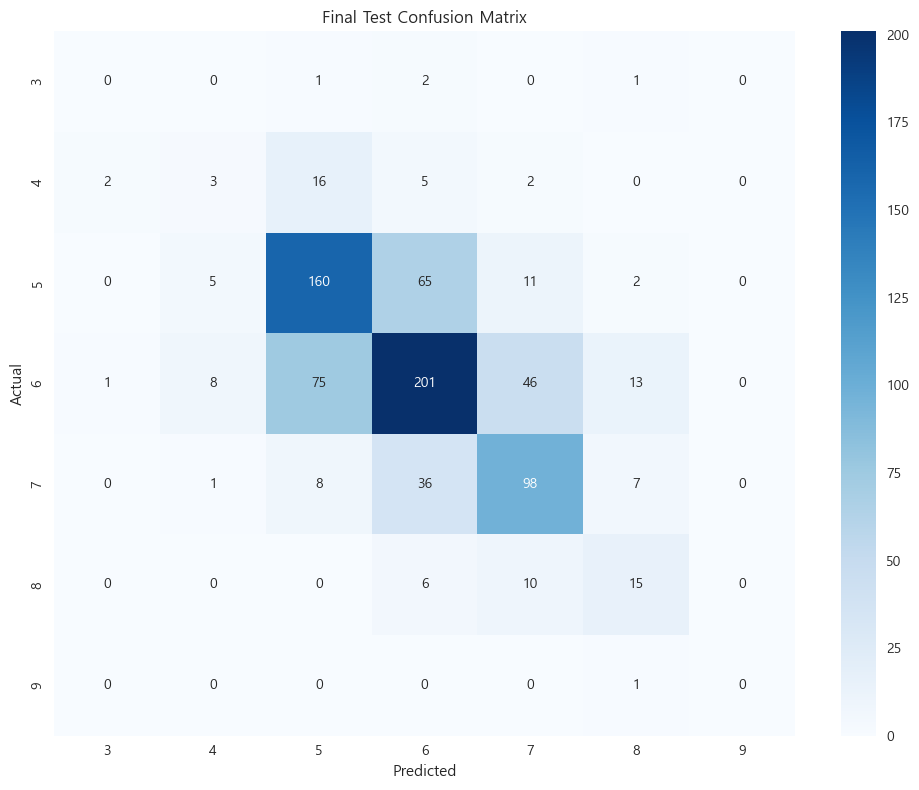

In [19]:
# 분류 모델 최종 평가
print("=" * 80)
print("=== 분류 모델 최종 평가 ===")
print("=" * 80)

# Test 데이터로 예측
y_pred_clf = best_clf_model.predict(X_test_scaled)

# 성능 지표 계산
test_accuracy = accuracy_score(y_test, y_pred_clf)
test_f1_macro = f1_score(y_test, y_pred_clf, average='macro')
test_f1_weighted = f1_score(y_test, y_pred_clf, average='weighted')

print(f"\n📊 최종 Test 성능 (분류):")
print(f"  Accuracy:    {test_accuracy:.4f}")
print(f"  F1 Macro:    {test_f1_macro:.4f}")
print(f"  F1 Weighted: {test_f1_weighted:.4f}")

# Classification Report
print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred_clf, zero_division=0))

# Confusion Matrix 시각화
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Test Confusion Matrix')
plt.tight_layout()
plt.show()

# MLflow에 최종 결과 로깅
with mlflow.start_run(run_name="RF_Classifier_FINAL_TEST"):
    mlflow.log_param("evaluation_type", "FINAL_TEST")
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_f1_macro", test_f1_macro)
    mlflow.log_metric("test_f1_weighted", test_f1_weighted)


=== 최종 결과 시각화 ===


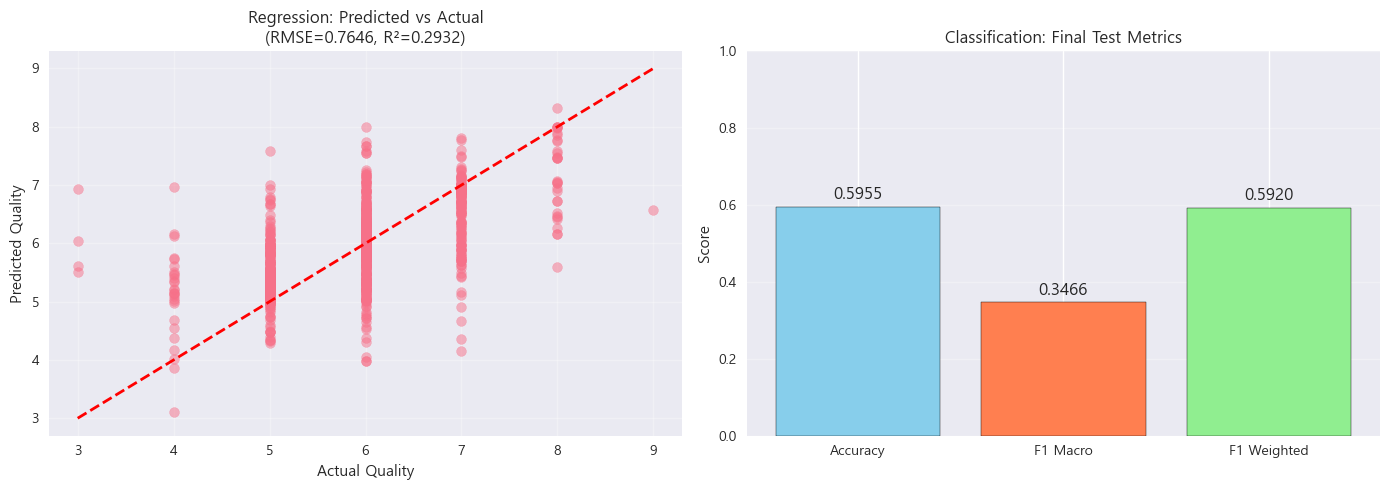

In [20]:
# 최종 결과 시각화
print("=" * 80)
print("=== 최종 결과 시각화 ===")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 회귀: 예측값 vs 실제값
axes[0].scatter(y_test, y_pred_reg, alpha=0.5, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Quality')
axes[0].set_ylabel('Predicted Quality')
axes[0].set_title(f'Regression: Predicted vs Actual\n(RMSE={test_rmse:.4f}, R²={test_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# 분류: 정확도 비교
metrics = ['Accuracy', 'F1 Macro', 'F1 Weighted']
values = [test_accuracy, test_f1_macro, test_f1_weighted]
colors = ['skyblue', 'coral', 'lightgreen']
bars = axes[1].bar(metrics, values, color=colors, edgecolor='black')
axes[1].set_ylabel('Score')
axes[1].set_title('Classification: Final Test Metrics')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [21]:
# 최종 요약
print("=" * 80)
print("🏁 Best Practice 워크플로우 완료!")
print("=" * 80)

print(f"""
📋 워크플로우 요약:
─────────────────────────────────────────────────────────────
1. 데이터 로드: {len(df)}개 샘플
2. Train/Test 분리: Train {len(X_train)}개, Test {len(X_test)}개 (먼저 분리!)
3. EDA: Train 데이터만으로 분석 (Test 봉인)
4. 전처리:
   - 결측치: Train 평균으로 처리
   - 이상치: Train에서 {n_outliers}개 제거
   - 피처 선택: {len(selected_features)}개 선택
   - 정규화: Train fit → Test transform
5. 샘플링: SMOTETomek (Train 내에서만)
   - 샘플링 후: {len(X_train_resampled)}개
6. 모델 학습: Train 데이터로 GridSearchCV
7. 최종 평가: 봉인된 Test 데이터로 단 한 번 평가

📊 최종 성능:
─────────────────────────────────────────────────────────────
회귀 모델:
  - RMSE: {test_rmse:.4f}
  - R²: {test_r2:.4f}
  - MAE: {test_mae:.4f}

분류 모델:
  - Accuracy: {test_accuracy:.4f}
  - F1 Macro: {test_f1_macro:.4f}
  - F1 Weighted: {test_f1_weighted:.4f}

💡 MLflow UI 확인:
   mlflow ui --backend-store-uri ./mlruns
""")

print("=" * 80)


🏁 Best Practice 워크플로우 완료!

📋 워크플로우 요약:
─────────────────────────────────────────────────────────────
1. 데이터 로드: 4001개 샘플
2. Train/Test 분리: Train 3200개, Test 801개 (먼저 분리!)
3. EDA: Train 데이터만으로 분석 (Test 봉인)
4. 전처리:
   - 결측치: Train 평균으로 처리
   - 이상치: Train에서 564개 제거
   - 피처 선택: 6개 선택
   - 정규화: Train fit → Test transform
5. 샘플링: SMOTETomek (Train 내에서만)
   - 샘플링 후: 8014개
6. 모델 학습: Train 데이터로 GridSearchCV
7. 최종 평가: 봉인된 Test 데이터로 단 한 번 평가

📊 최종 성능:
─────────────────────────────────────────────────────────────
회귀 모델:
  - RMSE: 0.7646
  - R²: 0.2932
  - MAE: 0.5477

분류 모델:
  - Accuracy: 0.5955
  - F1 Macro: 0.3466
  - F1 Weighted: 0.5920

💡 MLflow UI 확인:
   mlflow ui --backend-store-uri ./mlruns

